<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
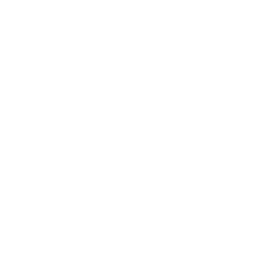
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interpolation der Einschreibung von Quartals- auf Monatswerte</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharma / Klinischer Betrieb &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Dieses durchgearbeitete Beispiel wandelt **quartalsweise** Einschreibungszahlen einer klinischen Studie mit PROC EXPAND in **monatliche** Schätzwerte um, damit die Ressourcenplanung auf Standortebene in einem monatlichen Takt erfolgen kann. Die synthetische Studie umfasst **vier Prüfzentren** in zwei Regionen (Nordamerika und Europa) über **acht Quartale** (Q1 2024 bis Q4 2025) und liefert damit **32 quartalsweise Beobachtungen**. PROC EXPAND interpoliert die Zeitreihe jedes Standorts von quartalsweiser auf monatliche Frequenz und macht aus diesen 32 Quartalszeilen **96 Monatszeilen**. Die Einschreibungszahlen werden mit `METHOD=JOIN` interpoliert (stückweise linear, wodurch jeder Schätzwert nicht-negativ bleibt) und die laufende Kumulation wird mit `METHOD=SPLINE` interpoliert. Die interpolierte Monatsreihe verläuft exakt durch die ursprünglichen quartalsweisen Stützpunkte, sodass die Umwandlung Details innerhalb des Quartals hinzufügt, ohne die bereits berichteten Quartalswerte der Studie zu verändern.


## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Quartalsweise Einschreibungszahlen nach Standort (4 Standorte x 8 Quartale) | 32 |
| WORK.SITE_MASTER | Standortreferenz: Name, Land, Region, PI | 4 |


---

In [1]:
/* --------------------------------------------------------
   Quartalsweise Einschreibungszahlen je Standort erzeugen.
   4 Standorte x 8 Quartale (Q1-2024 bis Q4-2025) = 32 Zeilen.
   Eine Anlaufkurve (langsamer Start, Plateau) plus ein leichter
   saisonaler Effekt und geringes Rauschen ergeben eine
   realistische Einschreibungsform.
   -------------------------------------------------------- */
DATEN work.enrollment_qtr;
    AUFRUFEN streaminit(42);
    format quarter_date yyq7.;
    FELD capacity[4] _temporary_ (12 9 14 8);
    AUSFÜHRUNG site_num = 1 BIS 4;
        site_id = cat('SITE-', PUT(site_num, z3.));
        region  = ifc(site_num <= 2, 'NORDAMERIKA', 'EUROPA');
        base_rate = capacity[site_num];
        AUSFÜHRUNG qtr_seq = 0 BIS 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            AUSGABE;
        ENDE;
    ENDE;
    ENTFERNEN site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
AUSFÜHREN;

/* Laufende kumulierte Einschreibung je Standort */
PROZEDUR SORTIEREN DATEN=work.enrollment_qtr;
    NACH site_id quarter_date;
AUSFÜHREN;

DATEN work.enrollment_qtr;
    FESTLEGEN work.enrollment_qtr;
    NACH site_id;
    BEHALTEN_W cum_enrolled 0;
    WENN first.site_id DANN cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    ENTFERNEN cum_enrolled;
AUSFÜHREN;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Standort-Stammdatentabelle (4 Standorte, 2 Regionen)
   -------------------------------------------------------- */
DATEN work.site_master;
    LÄNGE site_id $8 site_name $40 region $20 country $20 pi_name $30;
    FELD names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    FELD countries[4] $20 _temporary_ ('USA' 'USA' 'UK' 'Germany');
    AUSFÜHRUNG i = 1 BIS 4;
        site_id   = cat('SITE-', PUT(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'NORDAMERIKA', 'EUROPA');
        pi_name   = cat('Dr. Investigator-', PUT(i, z2.));
        AUSGABE;
    ENDE;
    ENTFERNEN i;
AUSFÜHREN;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline-Zusammenfassung der quartalsweisen Einschreibung nach Region
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.enrollment_qtr n sum mean MAX;
    KLASSE region;
    VAR enrolled_count cumulative_enrolled;
    BEZEICHNUNG region='Region'
          enrolled_count='Eingeschriebene Probanden'
          cumulative_enrolled='Kumulierte eingeschriebene Probanden';
    AUSGABE out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.qtr_baseline noobs;
    BEZEICHNUNG region='Region'
          total_enrolled='Gesamt eingeschrieben'
          avg_per_quarter='Durchschnitt je Quartal'
          max_cumulative='Maximale kumulierte Anzahl';
    TITEL 'Quartalsweise Einschreibungs-Baseline nach Region';
AUSFÜHREN;


                                                  The MEANS Procedure

                              Analysis Variable : enrolled_count Eingeschriebene Probanden

        Region               N Obs            Sum           Mean        Maximum
        -----------------------------------------------------------------------
        EUROPA                  16    120.0000000      7.5000000     13.0000000
        NORDAMERIKA             16    115.0000000      7.1875000     10.0000000
        -----------------------------------------------------------------------

                      Analysis Variable : cumulative_enrolled Kumulierte eingeschriebene Probanden

        Region               N Obs            Sum           Mean        Maximum
        -----------------------------------------------------------------------
        EUROPA                  16    493.0000000     30.8125000     81.0000000
        NORDAMERIKA             16    474.0000000     29.6250000     63.0000000
        --------


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


Die Ausgangsbasis bestätigt ein ausgewogenes Design: Jede Region trägt **16 quartalsweise Beobachtungen** bei. Nordamerika schreibt insgesamt **115 Probanden** ein (Mittelwert **7.19** pro Standort-Quartal) und Europa **120** (Mittelwert **7.50**). Die höchste über die acht Quartale erreichte kumulierte Zahl beträgt **81** Probanden (Europas SITE-003) gegenüber **63** in Nordamerika.


---

                                   Quartalsweise Einschreibungs-Baseline nach Region                                    




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


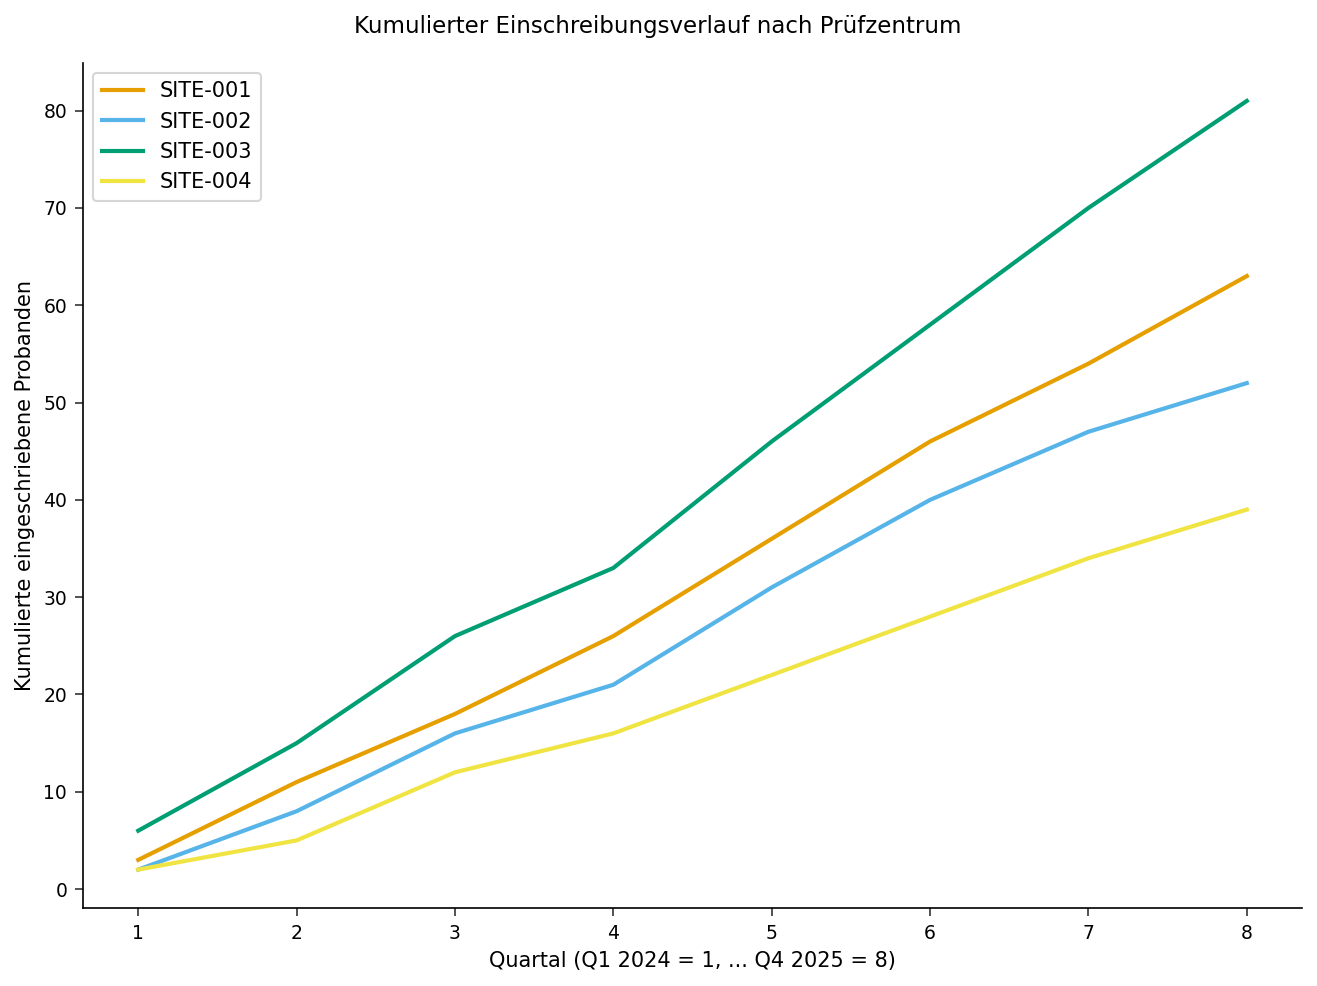

In [4]:
/* --------------------------------------------------------
   Quartalsweiser kumulierter Einschreibungsverlauf je Standort.
   Gegen einen Quartalsindex (1..8) für eine übersichtliche Achse
   dargestellt.
   -------------------------------------------------------- */
DATEN work.traj;
    FESTLEGEN work.enrollment_qtr;
    NACH site_id;
    BEHALTEN_W quarter_index 0;
    WENN first.site_id DANN quarter_index = 0;
    quarter_index + 1;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS BEZEICHNUNG='Quartal (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer VALUES=(1 BIS 8 NACH 1);
    YAXIS BEZEICHNUNG='Kumulierte eingeschriebene Probanden';
    TITEL 'Kumulierter Einschreibungsverlauf nach Prüfzentrum';
AUSFÜHREN;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND benötigt, dass die ID-Variable innerhalb jeder
   BY-Gruppe sortiert ist. Daher vor der Umwandlung nach Standort
   und Quartal sortieren.
   -------------------------------------------------------- */
PROZEDUR SORTIEREN DATEN=work.enrollment_qtr;
    NACH site_id quarter_date;
AUSFÜHREN;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Quartalsweise Einschreibung in monatliche Schätzwerte umwandeln.

   FROM=QTR / TO=MONTH in der PROC-Anweisung legen die Eingabe- und
   Ausgabefrequenz fest; PROC EXPAND interpoliert jede BY-Gruppe
   (Standort) unabhängig entlang des ID-Datums.

   enrolled_count      -> METHOD=JOIN   (stückweise linear; der
                          Flusswert bleibt zwischen den Stützpunkten
                          nicht-negativ)
   cumulative_enrolled -> METHOD=SPLINE (glatte monotone Kurve)
   -------------------------------------------------------- */
PROZEDUR expand DATEN=work.enrollment_qtr
            out=work.enrollment_monthly
            VON=qtr BIS=month;
    NACH site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=ENDE     METHOD=SPLINE;
AUSFÜHREN;


                                   Quartalsweise Einschreibungs-Baseline nach Region                                    




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                   Quartalsweise Einschreibungs-Baseline nach Region                                    




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


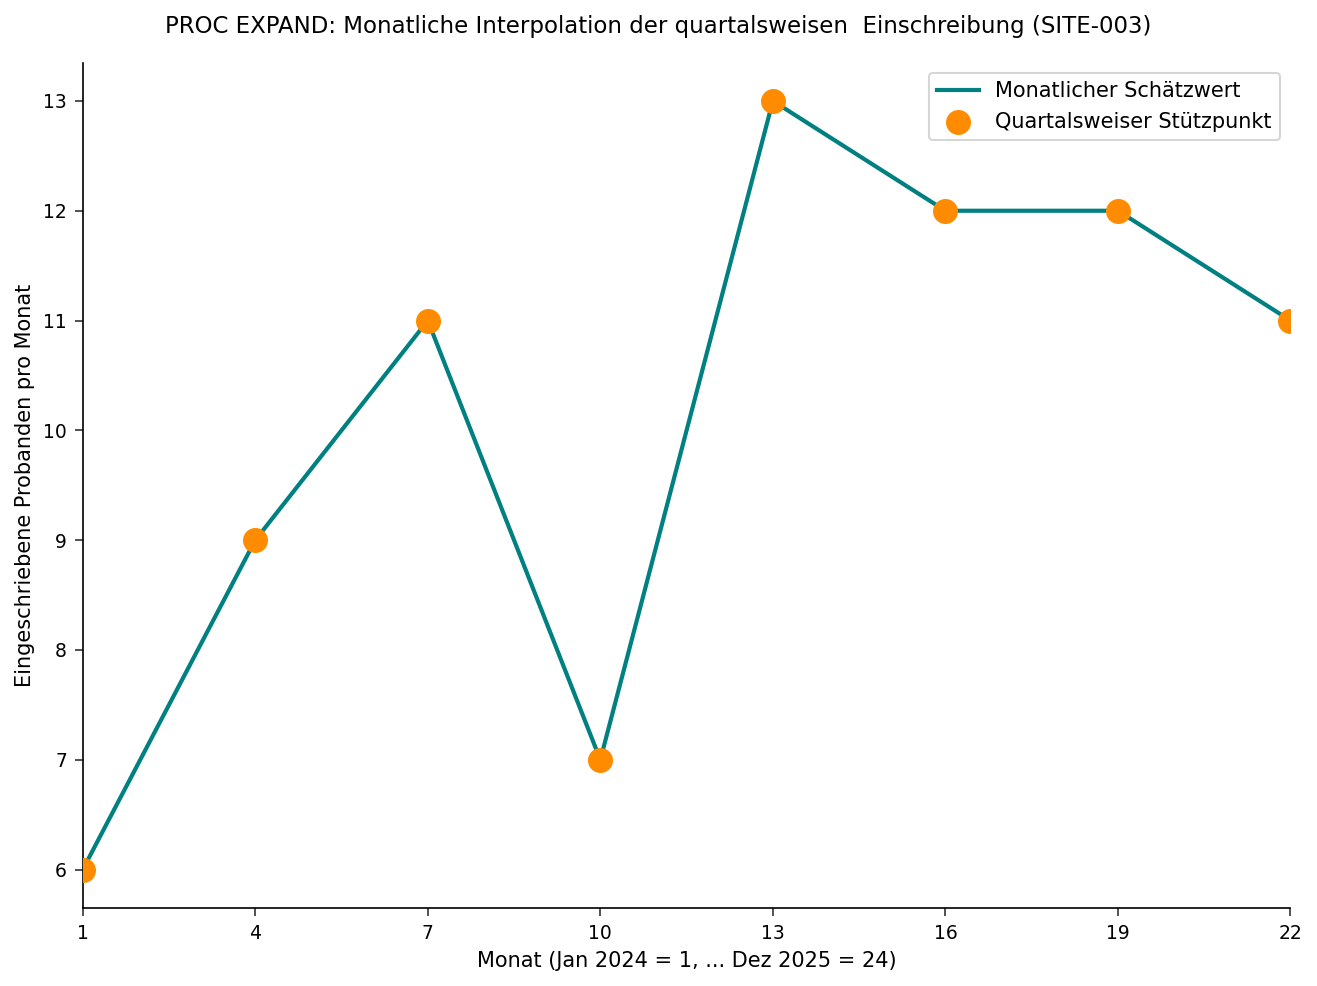

In [7]:
/* --------------------------------------------------------
   Die ID-Variable trägt jetzt monatliche Datumswerte. Neu
   formatieren und einen Monatsindex je Standort (1..24) für die
   Darstellung hinzufügen.
   -------------------------------------------------------- */
DATEN work.enrollment_monthly;
    FESTLEGEN work.enrollment_monthly;
    NACH site_id;
    format month_date monyy7.;
    month_date = quarter_date;
    BEHALTEN_W month_index 0;
    WENN first.site_id DANN month_index = 0;
    month_index + 1;
    /* Quartals-Stützpunktmonate markieren (1, 4, 7, ...) */
    WENN mod(month_index - 1, 3) = 0 DANN anchor = enrolled_count;
    SONST anchor = .;
AUSFÜHREN;

/* Umwandlung für einen Standort darstellen: die interpolierte
   monatliche Linie verläuft durch die ursprünglichen
   quartalsweisen Stützpunkte. */
PROZEDUR SGPLOT DATEN=work.enrollment_monthly;
    WO site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='Monatlicher Schätzwert';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='Quartalsweiser Stützpunkt';
    XAXIS BEZEICHNUNG='Monat (Jan 2024 = 1, ... Dez 2025 = 24)'
        integer VALUES=(1 BIS 24 NACH 3);
    YAXIS BEZEICHNUNG='Eingeschriebene Probanden pro Monat';
    TITEL 'PROC EXPAND: Monatliche Interpolation der quartalsweisen '
        'Einschreibung (SITE-003)';
AUSFÜHREN;


In [8]:
/* --------------------------------------------------------
   Monatliche Schätzwerte mit Standortmetadaten verknüpfen, dann
   die monatliche Einschreibung nach Region zusammenfassen.
   -------------------------------------------------------- */
PROZEDUR SQL;
    ERSTELLEN TABELLE work.enrollment_monthly_region AS
    AUSWÄHLEN e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    VON work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER NACH s.region, e.site_id, e.month_date;
QUIT;

PROZEDUR MITTELWERTE DATEN=work.enrollment_monthly_region n sum mean;
    KLASSE region;
    VAR monthly_estimate cumulative_estimate;
    BEZEICHNUNG region='Region'
          monthly_estimate='Monatlicher Schätzwert'
          cumulative_estimate='Kumulierter Schätzwert';
    AUSGABE out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.region_monthly_summary noobs;
    BEZEICHNUNG region='Region'
          total_monthly_enrolled='Monatlich eingeschrieben gesamt'
          avg_monthly_rate='Durchschnittliche monatliche Rate';
    TITEL 'Monatliche Schätzwerte nach Region';
AUSFÜHREN;


                                   Quartalsweise Einschreibungs-Baseline nach Region                                    

                                   Quartalsweise Einschreibungs-Baseline nach Region                                    

                                                  The MEANS Procedure

                              Analysis Variable : monthly_estimate Monatlicher Schätzwert

        Region               N Obs            Sum           Mean
        --------------------------------------------------------
        EUROPA                  44    336.0000000      7.6363636
        NORDAMERIKA             44    326.0000000      7.4090909
        --------------------------------------------------------

                            Analysis Variable : cumulative_estimate Kumulierter Schätzwert

        Region               N Obs            Sum           Mean
        --------------------------------------------------------
        EUROPA                  48   1367.0000


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Interpretation

PROC EXPAND wandelte die **32 quartalsweisen Datensätze** (4 Standorte x 8 Quartale) mittels Frequenzumwandlung entlang des Datums jedes Standorts in **96 monatliche Datensätze** um. Die interpolierte Monatsreihe verläuft exakt durch die ursprünglichen quartalsweisen Stützwerte, wie das SITE-003-Diagramm zeigt: Die orangefarbenen Punkte sind die acht berichteten Quartalswerte und die türkisfarbene Linie ist die disaggregierte monatliche Schätzung, die sie verbindet.

Auf Monatsebene verlaufen die beiden Regionen eng beieinander. Europa erreicht im Mittel **7.64** eingeschriebene Probanden pro Standort-Monat und Nordamerika **7.41**, bei regionalen Monatssummen von **336** und **326** Probanden über den interpolierten Zeithorizont. Da `METHOD=JOIN` nicht über den letzten quartalsweisen Stützpunkt hinaus extrapoliert, tragen die letzten Monate eines angebrochenen Quartals keinen Schätzwert und werden aus den Monatsmittelwerten ausgeschlossen, was die konservative Wahl für die Vorausplanung ist.

Diese monatlichen Projektionen ermöglichen es dem klinischen Betrieb, von einem quartalsweisen zu einem monatlichen Planungstakt überzugehen -- Dimensionierung von Arzneimittellieferungen, Terminierung von Monitoring-Besuchen und Meldung der Einschreibung an das Data Safety Monitoring Board -- ohne eine der quartalsweisen Zahlen, die die Studie bereits festgeschrieben hat, neu darzustellen.


---

In [9]:
/* --------------------------------------------------------
   Monatliche Einschreibungsprognosen für nachgelagerte
   Planungstools exportieren.
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>